In [219]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [220]:
df_basic = pd.read_csv('Basic_table.csv')
df_ad = pd.read_csv('Ad_table.csv')
df_sales = pd.read_csv('Sales_table.csv')

In [221]:
dataset = [df_basic, df_ad, df_sales, df_trim]
for df in dataset:
    df.columns = df.columns.str.replace(' ', '_') #a just-in-case the columns titled with a space, since it is easier for me to operate with underscore formatting
    df.columns = df.columns.str.lower()
#Creating new dataset specifically on used cars
df_used_cars = pd.merge(
    df_ad,
    df_basic,
    on = 'genmodel_id',
    how = 'inner'
)
df_used_cars = df_used_cars.dropna(subset = ['price', 'runned_miles']) #to ensure that all rows are used where we can conclude by looking at the Runned_Miles column
df_used_cars = df_used_cars.drop(columns = 'genmodel_y')

#after a careful observation, it looks like we need to make a new column here and drop the adv_year and adv_month
adv_month_padded = df_used_cars['adv_month'].astype(int).astype(str).str.zfill(2)
adv_year_str = df_used_cars['adv_year'].astype(int).astype(str)
df_used_cars['adv_period'] = adv_year_str + '-' + adv_month_padded
df_used_cars = df_used_cars.drop(columns = ['adv_year', 'adv_month'])

df_used_cars.info()
#as can be seen below, there are nulls on relatively irrelevant columns such as: color,  door_num, etc.
#but, seemingly relevant columns also have nulls (bodytype, engine_size, gearbox, and fuel_type)
#this issue will be addressed on the next cell.

<class 'pandas.core.frame.DataFrame'>
Index: 267200 entries, 0 to 268254
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   maker         267200 non-null  object 
 1   genmodel_x    267200 non-null  object 
 2   genmodel_id   267200 non-null  object 
 3   adv_id        267200 non-null  object 
 4   color         245488 non-null  object 
 5   reg_year      267200 non-null  float64
 6   bodytype      266272 non-null  object 
 7   runned_miles  267200 non-null  object 
 8   engin_size    265217 non-null  object 
 9   gearbox       267055 non-null  object 
 10  fuel_type     266803 non-null  object 
 11  price         267200 non-null  object 
 12  seat_num      260876 non-null  float64
 13  door_num      262724 non-null  float64
 14  automaker     267200 non-null  object 
 15  automaker_id  267200 non-null  int64  
 16  adv_period    267200 non-null  object 
dtypes: float64(3), int64(1), object(13)
memory usage: 36.

In [222]:
def fillna_bodytype (df, ID = 'genmodel_id', bt = 'bodytype'):
    #validating the columns existence
    if ID not in df.columns or bt not in df.columns:
        raise ValueError(f'No {ID} or {bt} found')

    #so that the real df is preserved
    df_copy = df.copy()

    df_copy[bt] = df_copy[bt].replace([r'^\s*$', 'NaN', 'nan'], np.nan, regex=True)# anticipating weird symbols on bodytype

    #finding the bodytype mode based on its id with groupby function
    group_mode = df_copy.groupby(ID)[bt].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
    df_copy[bt] = df_copy[bt].fillna(group_mode)

    return df_copy

df_used_cars = fillna_bodytype(df_used_cars)
df_used_cars = fillna_bodytype(df_used_cars, bt = 'engin_size')
df_used_cars = fillna_bodytype(df_used_cars, bt = 'gearbox')
df_used_cars = fillna_bodytype(df_used_cars, bt = 'fuel_type')
df_used_cars.info()

<class 'pandas.core.frame.DataFrame'>
Index: 267200 entries, 0 to 268254
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   maker         267200 non-null  object 
 1   genmodel_x    267200 non-null  object 
 2   genmodel_id   267200 non-null  object 
 3   adv_id        267200 non-null  object 
 4   color         245488 non-null  object 
 5   reg_year      267200 non-null  float64
 6   bodytype      267183 non-null  object 
 7   runned_miles  267200 non-null  object 
 8   engin_size    266879 non-null  object 
 9   gearbox       267195 non-null  object 
 10  fuel_type     267199 non-null  object 
 11  price         267200 non-null  object 
 12  seat_num      260876 non-null  float64
 13  door_num      262724 non-null  float64
 14  automaker     267200 non-null  object 
 15  automaker_id  267200 non-null  int64  
 16  adv_period    267200 non-null  object 
dtypes: float64(3), int64(1), object(13)
memory usage: 36.

In [223]:
'''
since some of the columns still have missing values,
yet we wanna see the trend of purchases for the columns,
it is better to delete the missing values and stick with the existing data
'''
df_used_cars = df_used_cars.dropna(subset = ['bodytype', 'gearbox', 'engin_size', 'fuel_type'])
#now we also do not wanna mess with other irrelevant missing values, so let us just fill it with unknown
df_used_cars = df_used_cars.fillna('Unknown')
#we also wanna change the dtype of engine_size to float
df_used_cars['engin_size'] = df_used_cars['engin_size'].astype(str).str.replace('L', '', case=False).str.strip()
df_used_cars['engin_size'] = pd.to_numeric(df_used_cars['engin_size'], errors='coerce')
df_used_cars.info()

<class 'pandas.core.frame.DataFrame'>
Index: 266860 entries, 0 to 268254
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   maker         266860 non-null  object 
 1   genmodel_x    266860 non-null  object 
 2   genmodel_id   266860 non-null  object 
 3   adv_id        266860 non-null  object 
 4   color         266860 non-null  object 
 5   reg_year      266860 non-null  float64
 6   bodytype      266860 non-null  object 
 7   runned_miles  266860 non-null  object 
 8   engin_size    266860 non-null  float64
 9   gearbox       266860 non-null  object 
 10  fuel_type     266860 non-null  object 
 11  price         266860 non-null  object 
 12  seat_num      266860 non-null  object 
 13  door_num      266860 non-null  object 
 14  automaker     266860 non-null  object 
 15  automaker_id  266860 non-null  int64  
 16  adv_period    266860 non-null  object 
dtypes: float64(2), int64(1), object(14)
memory usage: 36.

In [224]:
#perfect, now let us begin with merging df_used_cars with df_sales
#beforehand, let us make sure that df_sales also have genmodel_id and other relevant columns
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 773 entries, 0 to 772
Data columns (total 23 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   maker        773 non-null    object
 1   genmodel     773 non-null    object
 2   genmodel_id  773 non-null    object
 3   2020         773 non-null    int64 
 4   2019         773 non-null    int64 
 5   2018         773 non-null    int64 
 6   2017         773 non-null    int64 
 7   2016         773 non-null    int64 
 8   2015         773 non-null    int64 
 9   2014         773 non-null    int64 
 10  2013         773 non-null    int64 
 11  2012         773 non-null    int64 
 12  2011         773 non-null    int64 
 13  2010         773 non-null    int64 
 14  2009         773 non-null    int64 
 15  2008         773 non-null    int64 
 16  2007         773 non-null    int64 
 17  2006         773 non-null    int64 
 18  2005         773 non-null    int64 
 19  2004         773 non-null    

In [225]:
#it appears that the file is in a wide format, in order to merge it correctly, we have to reshape the file first.
#worth to note that we also are trying to address the possible duplicates when merging by cleaning the df_sales_melted
df_sales_melted = pd.melt(
    df_sales,
    id_vars = ['maker', 'genmodel', 'genmodel_id'], #keeps listed columns as columns
    var_name = 'sales_year', #makes a new column called sales_year consists of the sales year of each genmodel
    value_name = 'sales_volume', #and this new column which consists the sales volume of said genmodel
)
df_sales_melted['sales_year'] = pd.to_numeric(df_sales_melted['sales_year'], errors = 'coerce')
df_sales_melted.head()

,maker,genmodel,genmodel_id,sales_year,sales_volume
0,ABARTH,ABARTH 124,2_1,2020,0
1,ABARTH,ABARTH 500,2_2,2020,0
2,ABARTH,ABARTH 595,2_4,2020,2144
3,ABARTH,ABARTH 695,2_6,2020,45
4,ABARTH,ABARTH PUNTO,2_9,2020,0


In [226]:
#worth to note that we also are trying to address the possible duplicates when merging by cleaning the df_sales_melted
#now, let us merge df_used_cars with df_sales_melted
df_sales_clean = df_sales_melted.groupby(['genmodel_id', 'sales_year'])['sales_volume'].sum().reset_index()
df_analysis = pd.merge(
    df_used_cars,
    df_sales_clean,
    left_on = ['genmodel_id', 'reg_year'],
    right_on = ['genmodel_id', 'sales_year'],
    how = 'left'
)
df_analysis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266860 entries, 0 to 266859
Data columns (total 19 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   maker         266860 non-null  object 
 1   genmodel_x    266860 non-null  object 
 2   genmodel_id   266860 non-null  object 
 3   adv_id        266860 non-null  object 
 4   color         266860 non-null  object 
 5   reg_year      266860 non-null  float64
 6   bodytype      266860 non-null  object 
 7   runned_miles  266860 non-null  object 
 8   engin_size    266860 non-null  float64
 9   gearbox       266860 non-null  object 
 10  fuel_type     266860 non-null  object 
 11  price         266860 non-null  object 
 12  seat_num      266860 non-null  object 
 13  door_num      266860 non-null  object 
 14  automaker     266860 non-null  object 
 15  automaker_id  266860 non-null  int64  
 16  adv_period    266860 non-null  object 
 17  sales_year    237081 non-null  float64
 18  sale

In [227]:
#for bestpractice, we will reformat the columns and address the missing values
df_analysis.columns = [
    'maker', 'genmodel', 'genmodel_id', 'adv_id', 'color', 
    'reg_year', 'bodytype', 'mileage', 
    'engine_size', 'gearbox', 'fuel_type', 'price', 'seat_num', 
    'door_num', 'automaker', 'automaker_id', 'adv_period', 'sales_year', 'sales_volume'
]
df_analysis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266860 entries, 0 to 266859
Data columns (total 19 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   maker         266860 non-null  object 
 1   genmodel      266860 non-null  object 
 2   genmodel_id   266860 non-null  object 
 3   adv_id        266860 non-null  object 
 4   color         266860 non-null  object 
 5   reg_year      266860 non-null  float64
 6   bodytype      266860 non-null  object 
 7   mileage       266860 non-null  object 
 8   engine_size   266860 non-null  float64
 9   gearbox       266860 non-null  object 
 10  fuel_type     266860 non-null  object 
 11  price         266860 non-null  object 
 12  seat_num      266860 non-null  object 
 13  door_num      266860 non-null  object 
 14  automaker     266860 non-null  object 
 15  automaker_id  266860 non-null  int64  
 16  adv_period    266860 non-null  object 
 17  sales_year    237081 non-null  float64
 18  sale

In [228]:
#after a careful consideration, and visiting the Ad_table
#I found out that the possible missing values on the last 2 columns are caused by reg_year in Ad_table
#plenty of the cars were registered before 2001, hence the missing values we found on the info() above
#so, let us just delete the rows
df_analysis = df_analysis.dropna(subset = ['sales_volume'])
df_analysis.info()

<class 'pandas.core.frame.DataFrame'>
Index: 237081 entries, 1 to 266859
Data columns (total 19 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   maker         237081 non-null  object 
 1   genmodel      237081 non-null  object 
 2   genmodel_id   237081 non-null  object 
 3   adv_id        237081 non-null  object 
 4   color         237081 non-null  object 
 5   reg_year      237081 non-null  float64
 6   bodytype      237081 non-null  object 
 7   mileage       237081 non-null  object 
 8   engine_size   237081 non-null  float64
 9   gearbox       237081 non-null  object 
 10  fuel_type     237081 non-null  object 
 11  price         237081 non-null  object 
 12  seat_num      237081 non-null  object 
 13  door_num      237081 non-null  object 
 14  automaker     237081 non-null  object 
 15  automaker_id  237081 non-null  int64  
 16  adv_period    237081 non-null  object 
 17  sales_year    237081 non-null  float64
 18  sales_vol

In [229]:
df_analysis['sales_year'] = df_analysis['sales_year'].fillna(0).astype(int)
df_analysis['sales_year'] = df_analysis['sales_year'].astype(str)
df_analysis['sales_volume'] = df_analysis['sales_volume'].astype(int)
df_analysis['mileage'] = df_analysis['mileage'].astype(str).str.replace(',', '').str.strip()
df_analysis['mileage'] = pd.to_numeric(df_analysis['mileage'], errors='coerce')
df_analysis = df_analysis.dropna(subset=['mileage'])

df_analysis = df_analysis.drop_duplicates(subset=['genmodel_id', 'reg_year', 'sales_volume'])
df_analysis.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3889 entries, 1 to 266857
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   maker         3889 non-null   object 
 1   genmodel      3889 non-null   object 
 2   genmodel_id   3889 non-null   object 
 3   adv_id        3889 non-null   object 
 4   color         3889 non-null   object 
 5   reg_year      3889 non-null   float64
 6   bodytype      3889 non-null   object 
 7   mileage       3889 non-null   float64
 8   engine_size   3889 non-null   float64
 9   gearbox       3889 non-null   object 
 10  fuel_type     3889 non-null   object 
 11  price         3889 non-null   object 
 12  seat_num      3889 non-null   object 
 13  door_num      3889 non-null   object 
 14  automaker     3889 non-null   object 
 15  automaker_id  3889 non-null   int64  
 16  adv_period    3889 non-null   object 
 17  sales_year    3889 non-null   object 
 18  sales_volume  3889 non-null   i

In [230]:
df_analysis.head()

,maker,genmodel,genmodel_id,adv_id,color,reg_year,bodytype,mileage,engine_size,gearbox,fuel_type,price,seat_num,door_num,automaker,automaker_id,adv_period,sales_year,sales_volume
1,Bentley,Arnage,10_1,10_1$$2,Grey,2002.0,Saloon,44000.0,6.8,Automatic,Petrol,28750,5.0,4.0,Bentley,10,2018-06,2002,134
3,Bentley,Arnage,10_1,10_1$$4,Green,2003.0,Saloon,14000.0,6.8,Automatic,Petrol,34948,5.0,4.0,Bentley,10,2018-04,2003,106
31,Bentley,Bentayga,10_3,10_3$$1,Grey,2016.0,SUV,12661.0,6.0,Automatic,Petrol,129990,5.0,5.0,Bentley,10,2018-03,2016,342
32,Bentley,Bentayga,10_3,10_3$$2,Brown,2018.0,SUV,415.0,6.0,Automatic,Petrol,164995,5.0,5.0,Bentley,10,2018-04,2018,526
37,Bentley,Bentayga,10_3,10_3$$7,Grey,2017.0,SUV,10972.0,6.0,Automatic,Petrol,139950,5.0,5.0,Bentley,10,2018-08,2017,545


It is quiet intriguing that we actually deal with this many of data, now i learned the importance of dropping duplicates

# Exploratory Data Analysis

## Straight to Visualization

For EDA, we jump straight to visualization and analyze it statistically once we find something intriguing

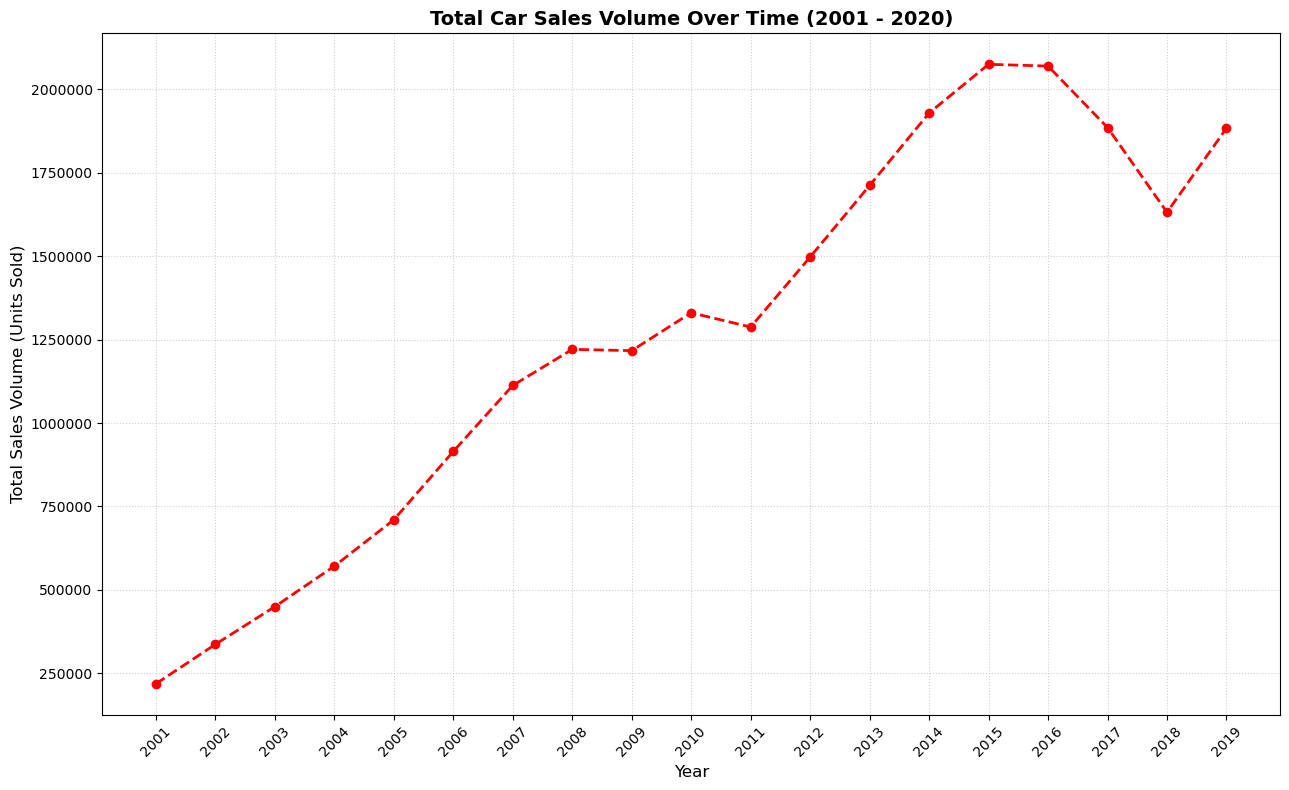

In [231]:
df_yearly_sales = df_analysis.groupby('sales_year')['sales_volume'].sum().reset_index()
df_yearly_sales['sales_year'] = df_yearly_sales['sales_year'].astype(int)
df_yearly_sales = df_yearly_sales.sort_values('sales_year')

plt.figure(figsize = (13,8))

plt.plot(
    df_yearly_sales['sales_year'], 
    df_yearly_sales['sales_volume'], 
    marker='o', 
    linestyle='--', 
    color='r',
    linewidth=2
)
plt.xticks(df_yearly_sales['sales_year'], rotation=45)

plt.title('Total Car Sales Volume Over Time (2001 - 2020)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Sales Volume (Units Sold)', fontsize=12)
plt.ticklabel_format(style = 'plain', axis = 'y')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [232]:
import statsmodels.api as sm
X = df_yearly_sales['sales_year']
Y = df_yearly_sales['sales_volume']

X_with_const = sm.add_constant(X)
trend_model = sm.OLS(Y, X_with_const).fit()

slope_value = trend_model.params['sales_year']
print(f"Nilai Gradien (Tren Tahunan): {slope_value:.2f}")
print(trend_model.summary())

Nilai Gradien (Tren Tahunan): 101232.93
                            OLS Regression Results                            
Dep. Variable:           sales_volume   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.897
Method:                 Least Squares   F-statistic:                     158.2
Date:                Tue, 30 Jun 2026   Prob (F-statistic):           4.88e-10
Time:                        14:31:03   Log-Likelihood:                -257.06
No. Observations:                  19   AIC:                             518.1
Df Residuals:                      17   BIC:                             520.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -

To make it simple, the trend as visible is indeed an uptrend with the m or slope value of approx 101,200.
Earlier, we might have a negative assumption about what had happened in 2018 might mean a depleting selling from 2018 and continuosly. But, the slope test results in 'the uptrend of the sales is significant and not a coincidence.' Therefore, we can remain positive about future selling.

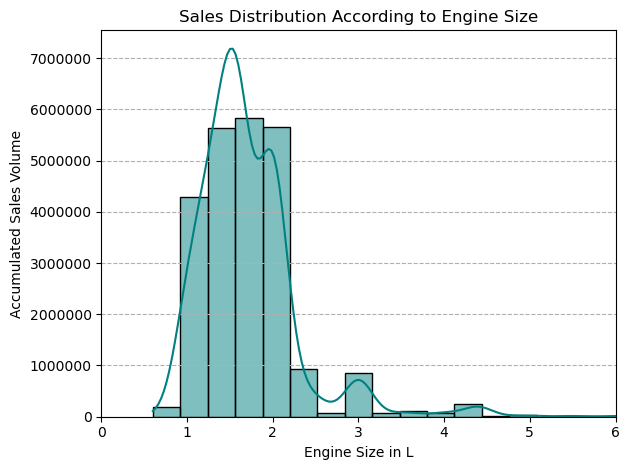

In [233]:
sns.histplot(df_analysis, x = 'engine_size', weights = 'sales_volume', kde = True, bins = 20, color = 'teal')
#tidying up the data
plt.title('Sales Distribution According to Engine Size')
plt.xlabel('Engine Size in L')
plt.ylabel('Accumulated Sales Volume')
plt.ticklabel_format(style = 'plain', axis = 'y')
plt.grid(axis = 'y', linestyle = '--')

plt.xlim(0, 6.0)#this is to limit the x so that our data is not polluted with outliers which are massive machines of trucks and rare supercars
plt.tight_layout()
plt.show()

This is just a curious observation about what engine size is the most preferable, and the answer is self explanatory just by looking at the chart. The most preferable engine size is those within the range of 1.0-2.0 liters. To confirm whether stocking more of cars with this size of machines will affect our sales positively will be tested in the next cell

In [234]:
#agregating the data
df_engine_corr = df_analysis.groupby(['genmodel_id', 'engine_size'])['sales_volume'].sum().reset_index()
df_engine_corr = df_engine_corr.dropna(subset=['engine_size', 'sales_volume'])
#putting in the calculations
pearson_corr = df_engine_corr['engine_size'].corr(df_engine_corr['sales_volume'], method='pearson')
spearman_corr = df_engine_corr['engine_size'].corr(df_engine_corr['sales_volume'], method='spearman')
print(f"Koefisien Korelasi Pearson : {pearson_corr:.4f}")
print(f"Koefisien Korelasi Spearman: {spearman_corr:.4f}")

Koefisien Korelasi Pearson : -0.1875
Koefisien Korelasi Spearman: -0.4060


The answer is not really, but to understand it visually, let us take a look into a scatterplot

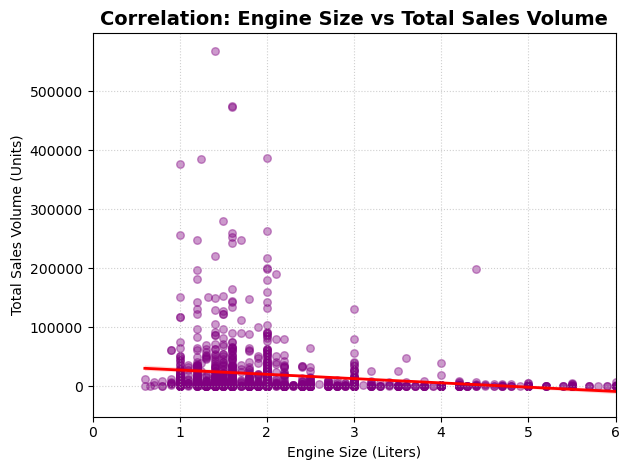

In [235]:
sns.regplot(
    data=df_engine_corr, 
    x='engine_size', 
    y='sales_volume', 
    color='purple', 
    scatter_kws={'alpha': 0.4, 's': 30},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title('Correlation: Engine Size vs Total Sales Volume', fontsize=14, fontweight='bold')
plt.xlabel('Engine Size (Liters)')
plt.ylabel('Total Sales Volume (Units)')
plt.ticklabel_format(style = 'plain', axis = 'y')
plt.xlim(0, 6.0) # Limiting the size just like before
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

As aforementioned, stocking more cars with the most preferred engine capacity does not affect our sales.


Now, let us check about mileage statistics

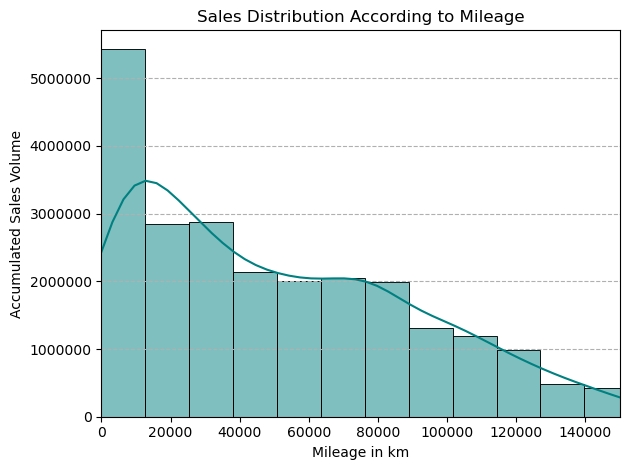

In [236]:
sns.histplot(df_analysis, x = 'mileage', weights = 'sales_volume', kde = True, bins = 50, color = 'teal')
#tidying up the data
plt.title('Sales Distribution According to Mileage')
plt.xlabel('Mileage in km')
plt.xlim(0,150000) #because the frequency of data beyond 150k is too little
plt.ylabel('Accumulated Sales Volume')
plt.ticklabel_format(style = 'plain', axis = 'y')
plt.grid(axis = 'y', linestyle = '--')

plt.tight_layout()
plt.show()

Quiet a reflection towards the actual condition of the real market, where people prefer cars with low mileage.

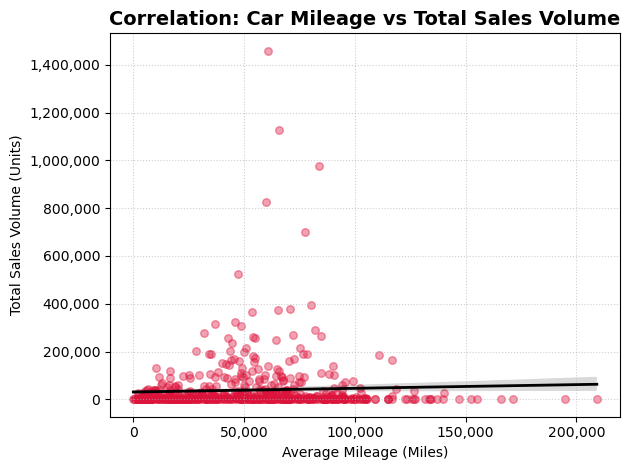

In [237]:
df_mileage_corr = df_analysis.groupby('genmodel_id').agg({
    'mileage': 'mean', 
    'sales_volume': 'sum'
}).reset_index()
df_mileage_corr = df_mileage_corr.dropna(subset=['mileage', 'sales_volume'])

sns.regplot(
    data=df_mileage_corr, 
    x='mileage', 
    y='sales_volume', 
    color='crimson', 
    scatter_kws={'alpha': 0.4, 's': 30},
    line_kws={'color': 'black', 'linewidth': 2}
)

# Format ribuan untuk sumbu X dan Y agar scannable
ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x):,}'))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x):,}'))

plt.title('Correlation: Car Mileage vs Total Sales Volume', fontsize=14, fontweight='bold')
plt.xlabel('Average Mileage (Miles)') 
plt.ylabel('Total Sales Volume (Units)')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

Just like before, even mileage does not affect our selling. But, one thing that we can conclude is:
the more car with lower mileage and small engine size we stock, the more people would be interested to buy.

For instance, people do look for the aforementioned quality in cars, but that does not imply that adding or stocking more cars with that quality will attract more buyer. Purchases only happen when there is actually a demand for the car and we happen to have in our garage. One thing to be sure of is that our sales will certainly keep increasing.

In [250]:
df_maker_sales = df_analysis.drop_duplicates(subset = ['genmodel_id', 'reg_year', 'sales_volume'])

shown_makers = df_maker_sales.groupby('maker')['sales_volume'].sum().sort_values(ascending = False).reset_index().head(8)
top_makers = shown_makers['maker'].head(3).tolist()

colors = ['red' if maker in top_makers else 'mistyrose' for maker in shown_makers['maker']]

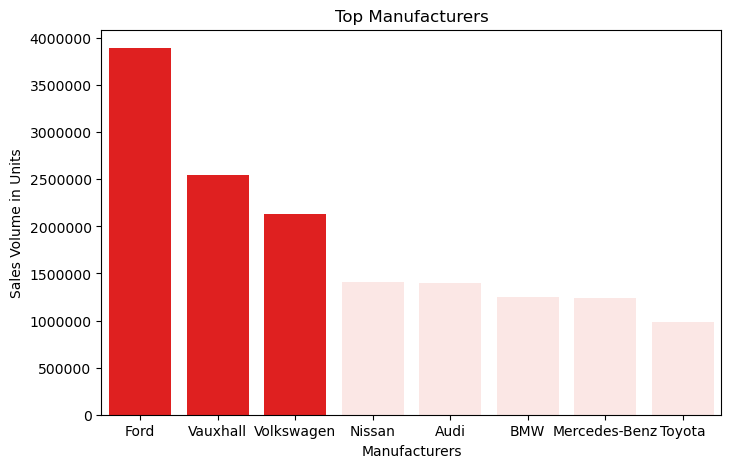

In [251]:
plt.figure(figsize = (8,5))

sns.barplot(shown_makers, x = 'maker', y = 'sales_volume', palette = colors)

plt.title('Top Manufacturers')
plt.xlabel('Manufacturers')
plt.ylabel('Sales Volume in Units')
plt.ticklabel_format(style = 'plain', axis = 'y')

plt.show()

Top preferred manufacturers as shown is Ford, Vauxhall, and Volkswagen. But, does stocking these cars actually improve the sales? Let us find out.

In [253]:
from statsmodels.formula.api import ols

model = ols('sales_volume ~ C(maker)', data = df_maker_sales).fit()

anova_table = sm.stats.anova_lm(model, typ = 2)
print(anova_table)

                sum_sq      df          F        PR(>F)
C(maker)  7.863834e+10    63.0  10.810118  8.737711e-95
Residual  4.416668e+11  3825.0        NaN           NaN


By the statistical math, from the sum_sq column, we get that the eta squared which represents the corelation squared, at around 15%, which means the corelation is 0.39. This implies that the cars we get from each manufacturers is most likely affecting our sales! Moreover, the PR(>F)n number for the maker feature is much lower than 0.05, which also supports the conclusion! So, yeah, we have to scout for more cars from Ford, Vauxhall, or Volkswagen. Now, let us move on whether the bodytype also affects our sales.

In [260]:
df_bodytype_sales = df_analysis.drop_duplicates(subset = ['genmodel_id', 'reg_year', 'sales_volume'])

shown_bodytype = df_maker_sales.groupby('bodytype')['sales_volume'].sum().sort_values(ascending = False).reset_index().head(8)
top_bodytype = shown_bodytype['bodytype'].head(3).tolist()

colors = ['deepskyblue' if bodytype in top_bodytype else 'skyblue' for bodytype in shown_bodytype['bodytype']]

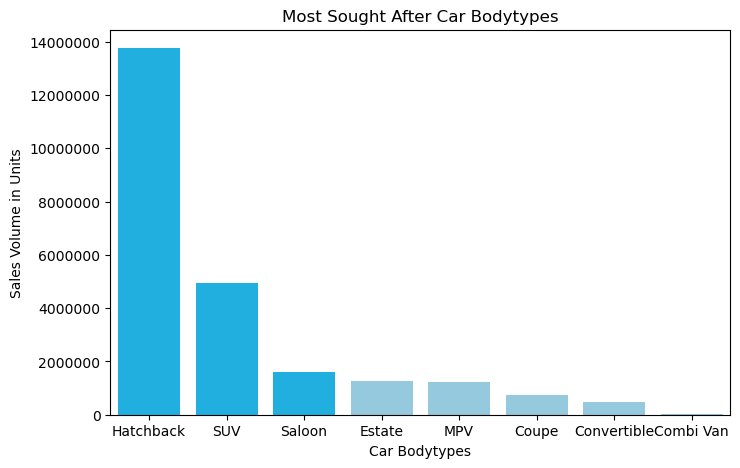

In [261]:
plt.figure(figsize = (8,5))

sns.barplot(shown_bodytype, x = 'bodytype', y = 'sales_volume', palette = colors)

plt.title('Most Sought After Car Bodytypes')
plt.xlabel('Car Bodytypes')
plt.ylabel('Sales Volume in Units')
plt.ticklabel_format(style = 'plain', axis = 'y')

plt.show()

Let us test again, whether this affects our sales.

In [262]:
model = ols('sales_volume ~ C(bodytype)', data = df_bodytype_sales).fit()

anova_table = sm.stats.anova_lm(model, typ = 2)
print(anova_table)

                   sum_sq      df          F        PR(>F)
C(bodytype)  6.238442e+10    12.0  44.003613  1.847872e-98
Residual     4.579207e+11  3876.0        NaN           NaN


With the same math as before, the answer is yes! The equivalent correlation is 0.35 which means it is also moderately affecting our sales, and the statement is backed with the super low number of PR(>F). So, we might also want to stock more hatchbacks and SUVs.